In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [22]:
data = pd.read_csv("/content/DailyDelhiClimateTest.csv")
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,01-01-2017,15.913043,85.869565,2.743478,59.000000
1,02-01-2017,18.500000,77.222222,2.894444,1018.277778
2,03-01-2017,17.111111,81.888889,4.016667,1018.333333
3,04-01-2017,18.700000,70.050000,4.545000,1015.700000
4,05-01-2017,18.388889,74.944444,3.300000,1014.333333


In [23]:
if data.index.name == 'date':
    data.reset_index(inplace=True)
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y')
data.set_index('date', inplace=True)
data['humidity_diff'] = data['humidity']-data['humidity'].shift(1)
result = seasonal_decompose(data['humidity'], model='additive', period=12)
data['humidity_sea_diff'] = result.resid
data['humidity_log'] = np.log(data['humidity'])
data['humidity_log_diff'] = data['humidity_log']-data['humidity_log'].shift(1)
result = seasonal_decompose(data['humidity_log_diff'].dropna(), model='additive', period=12)
data['humidity_log_sea_diff'] = result.resid

Text(0, 0.5, 'Humidity')

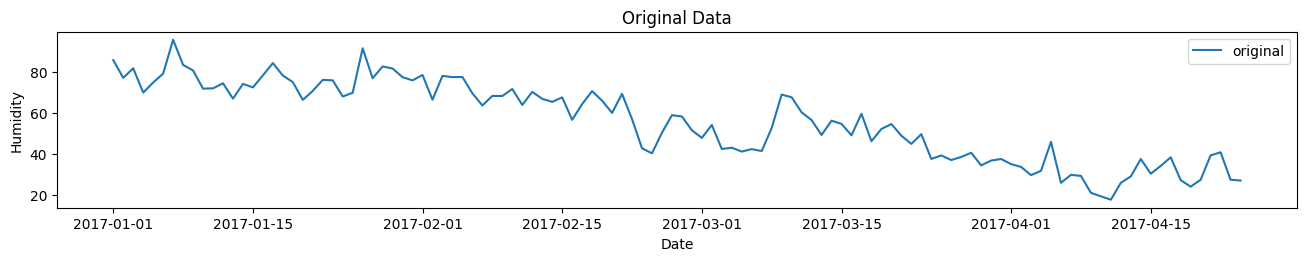

In [24]:
plt.figure(figsize=(16,16))
plt.subplot(6,1,1)
plt.plot(data['humidity'],label = 'original')
plt.legend(loc = 'best')
plt.title('Original Data')
plt.xlabel('Date')
plt.ylabel('Humidity')

Text(0, 0.5, 'Humidity')

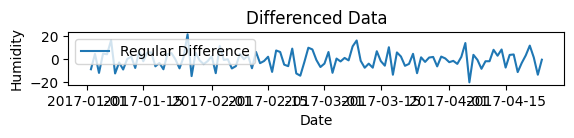

In [25]:
plt.subplot(6,1,2)
plt.plot(data['humidity_diff'],label = 'Regular Difference')
plt.legend(loc = 'best')
plt.title('Differenced Data')
plt.xlabel('Date')
plt.ylabel('Humidity')

Text(0, 0.5, 'Humidity')

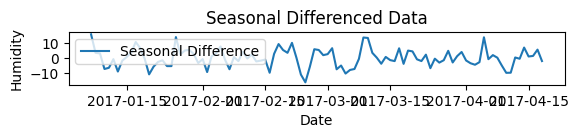

In [26]:
plt.subplot(6,1,3)
plt.plot(data['humidity_sea_diff'],label = 'Seasonal Difference')
plt.legend(loc = 'best')
plt.title('Seasonal Differenced Data')
plt.xlabel('Date')
plt.ylabel('Humidity')

Text(0, 0.5, 'Humidity')

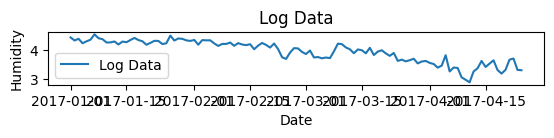

In [27]:
plt.subplot(6,1,4)
plt.plot(data['humidity_log'],label = 'Log Data')
plt.legend(loc = 'best')
plt.title('Log Data')
plt.xlabel('Date')
plt.ylabel('Humidity')

Text(0, 0.5, 'Humidity')

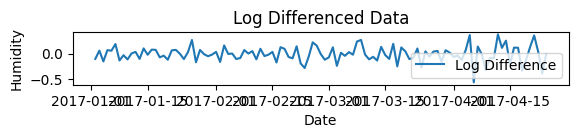

In [28]:
plt.subplot(6,1,5)
plt.plot(data['humidity_log_diff'],label = 'Log Difference')
plt.legend(loc = 'best')
plt.title('Log Differenced Data')
plt.xlabel('Date')
plt.ylabel('Humidity')


Text(0, 0.5, 'Humidity')

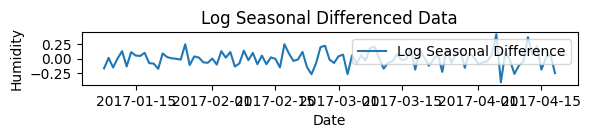

In [29]:
plt.subplot(6,1,6)
plt.plot(data['humidity_log_sea_diff'],label = 'Log Seasonal Difference')
plt.legend(loc = 'best')
plt.title('Log Seasonal Differenced Data')
plt.xlabel('Date')
plt.ylabel('Humidity')